<a href="https://colab.research.google.com/github/rya4sure/PSD/blob/rya-ganteng/Signal_and_Alliasing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import square

A = 1
freq_list = [2, 10, 20]
fs = 1000
T = 1

time_axis = np.arange(0, T, 1/fs)
preview = 200

In [ ]:
def analyze_signal(signal_set, label):

    total_samples = len(time_axis)

    # ===== Time Domain =====
    fig1, ax1 = plt.subplots(1, 3, figsize=(15,4))

    for idx in range(3):
        ax1[idx].plot(time_axis[:preview], signal_set[idx][:preview])
        ax1[idx].set_title(f"{freq_list[idx]} Hz")
        ax1[idx].set_ylim(-2, 2)
        ax1[idx].grid()

    fig1.suptitle(f"Domain Waktu - {label}")
    plt.tight_layout()
    plt.show()

    # ===== Frequency Domain =====
    fig2, ax2 = plt.subplots(1, 3, figsize=(15,4))

    for idx in range(3):
        spectrum = np.fft.fft(signal_set[idx])
        freq_axis = np.fft.fftfreq(total_samples, 1/fs)

        ax2[idx].plot(freq_axis[:total_samples//2],
                      np.abs(spectrum[:total_samples//2]) / total_samples)
        ax2[idx].set_xlim(0, 100)
        ax2[idx].set_title(f"{freq_list[idx]} Hz")
        ax2[idx].grid()

    fig2.suptitle(f"Domain Frekuensi (FFT) - {label}")
    plt.tight_layout()
    plt.show()

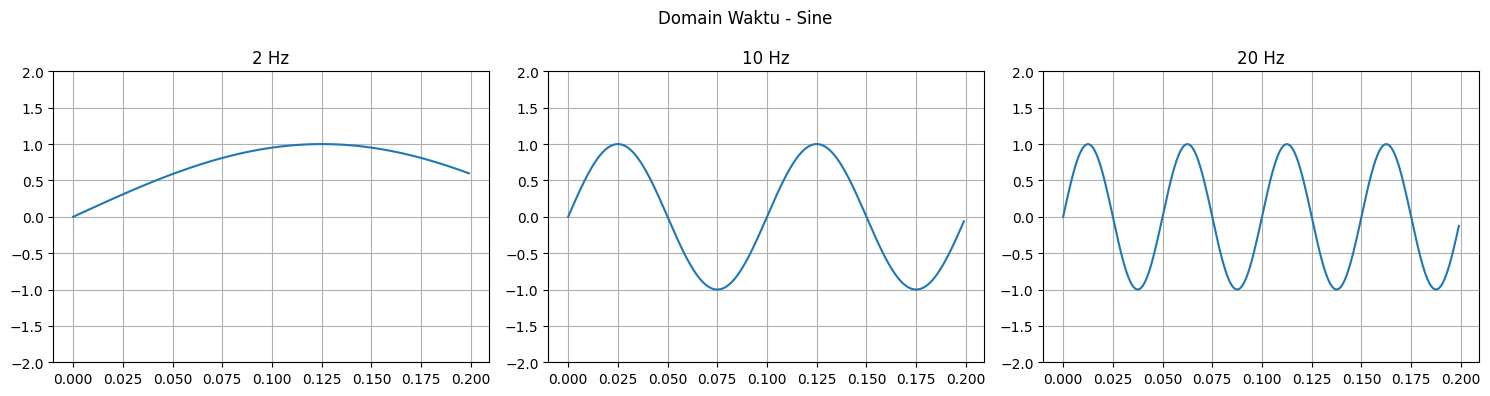

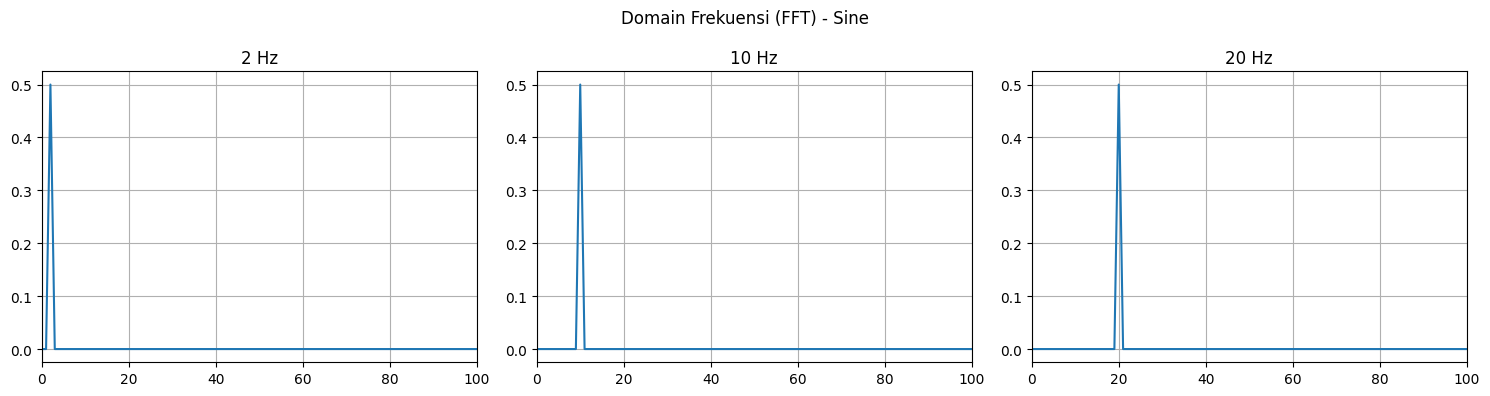

In [ ]:
sinusoidal = []

for f in freq_list:
    sinusoidal.append(A * np.sin(2*np.pi*f*time_axis))

analyze_signal(sinusoidal, "Sine")

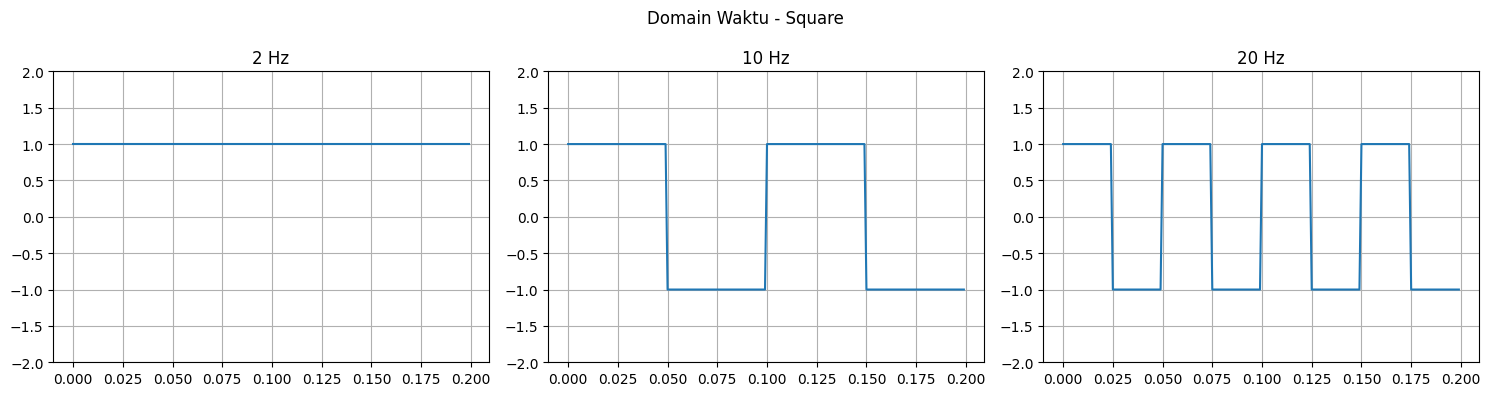

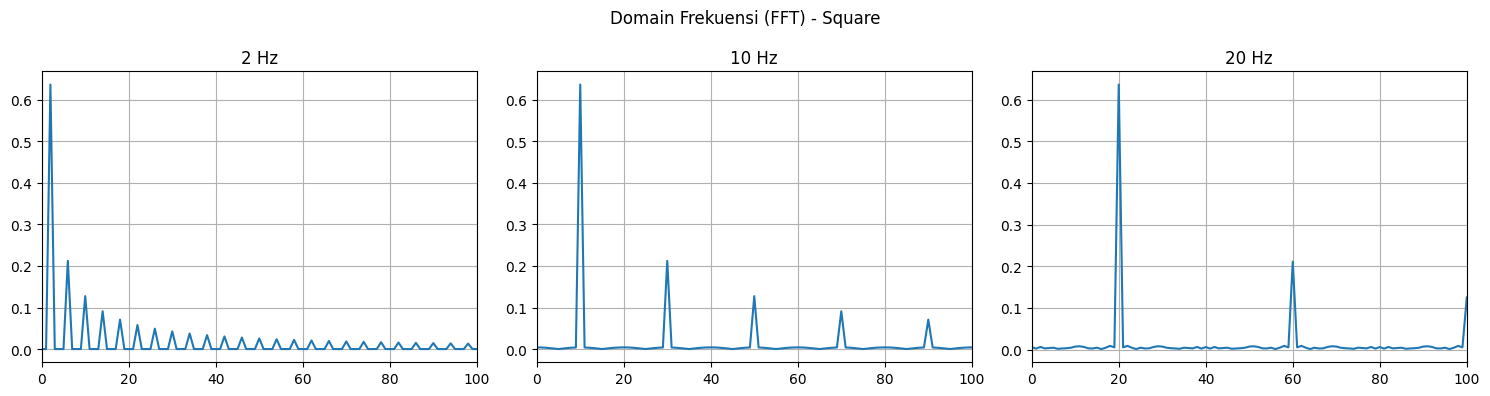

In [ ]:
square_wave = []

for f in freq_list:
    square_wave.append(A * square(2*np.pi*f*time_axis))

analyze_signal(square_wave, "Square")

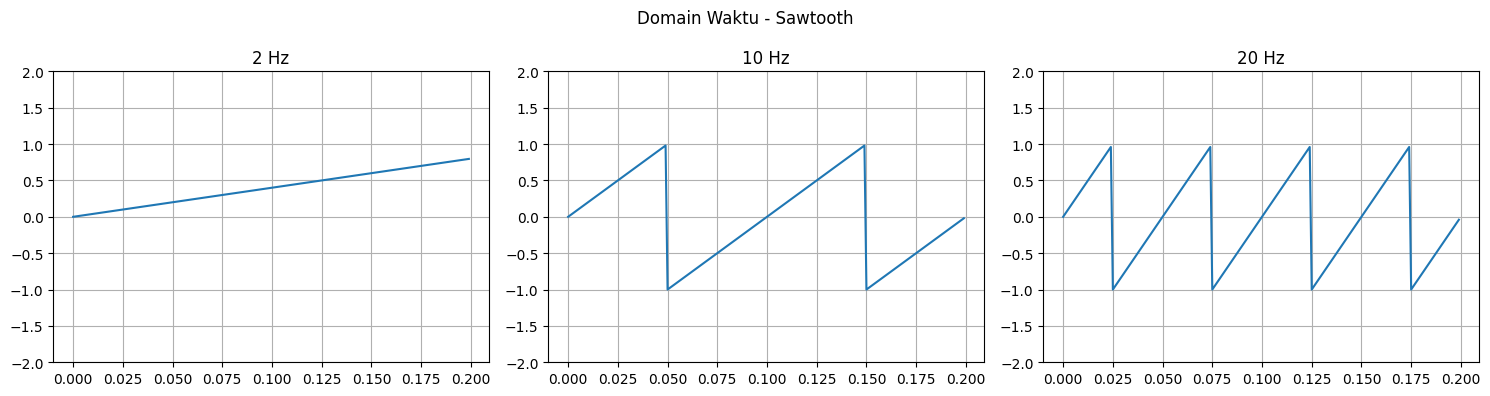

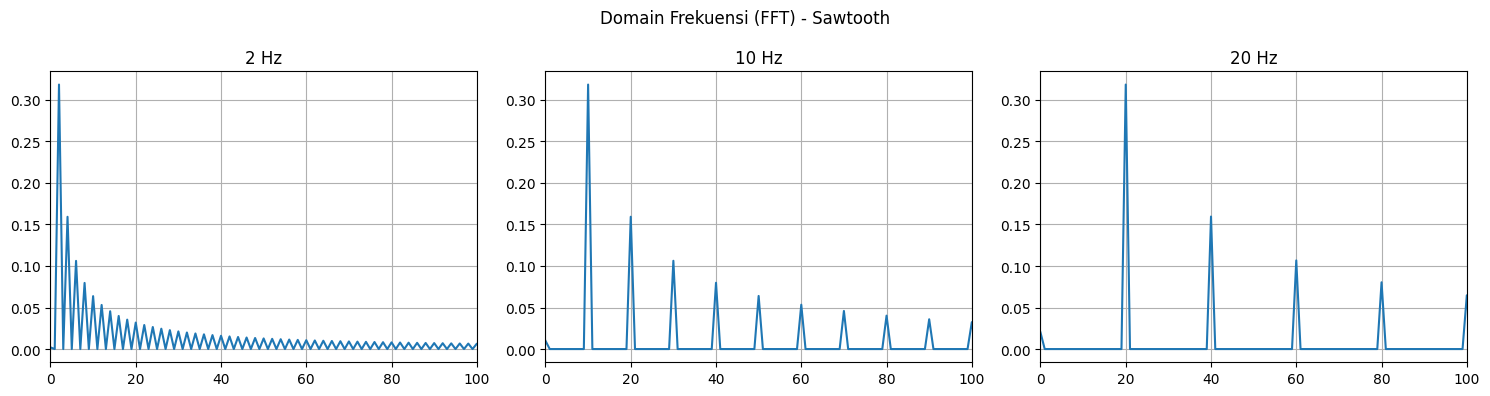

In [ ]:
saw_wave = []

for f in freq_list:
    saw_wave.append(A * (2*(time_axis*f - np.floor(0.5 + time_axis*f))))

analyze_signal(saw_wave, "Sawtooth")

**Sinyal sinus (sine wave)**
Merupakan sinyal paling halus dan kontinu. Perubahannya gradual tanpa diskontinuitas. Pada domain frekuensi (FFT), sinyal ini hanya memiliki satu komponen frekuensi utama, yaitu frekuensi dasarnya saja. Karena bentuknya murni, tidak muncul harmonisa tambahan.

**Sinyal kotak (square wave)**
Memiliki perubahan yang sangat tajam antara nilai maksimum dan minimum. Transisi instan ini menyebabkan munculnya banyak komponen harmonisa. Pada spektrum frekuensi terlihat frekuensi dasar serta deret harmonisa ganjil (3f, 5f, 7f, dan seterusnya). Semakin tinggi harmonisa, semakin kecil amplitudonya.

**Sinyal gigi gergaji (sawtooth wave)**
Memiliki pola naik atau turun secara linear lalu jatuh secara tiba-tiba. Berbeda dari square wave, sinyal ini mengandung harmonisa ganjil dan genap. Karena jumlah komponen frekuensinya lebih banyak, spektrum terlihat lebih padat dibandingkan dua sinyal lainnya.

In [ ]:
def alias_demo(original_freq, sampling_low):

    fs_high = 5000
    t_high = np.arange(0, 1, 1/fs_high)

    signal_high = np.sin(2*np.pi*original_freq*t_high)

    t_sampled = np.arange(0, 1, 1/sampling_low)
    sampled_signal = np.sin(2*np.pi*original_freq*t_sampled)

    alias_freq = abs(original_freq - sampling_low *
                     round(original_freq / sampling_low))

    reconstructed = np.sin(2*np.pi*alias_freq*t_high)

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(t_high, signal_high, alpha=0.4, label="Original")
    plt.plot(t_high, reconstructed, label="Aliased")
    plt.stem(t_sampled, sampled_signal, basefmt=" ")
    plt.title("Aliasing in Time Domain")
    plt.legend()
    plt.grid()

    fft_result = np.fft.fft(sampled_signal)
    freq_axis = np.fft.fftfreq(len(sampled_signal), 1/sampling_low)

    plt.subplot(1,2,2)
    plt.stem(freq_axis[:len(sampled_signal)//2],
             np.abs(fft_result[:len(sampled_signal)//2]) / len(sampled_signal),
             basefmt=" ")
    plt.title("Aliasing in Frequency Domain")
    plt.grid()

    plt.tight_layout()
    plt.show()

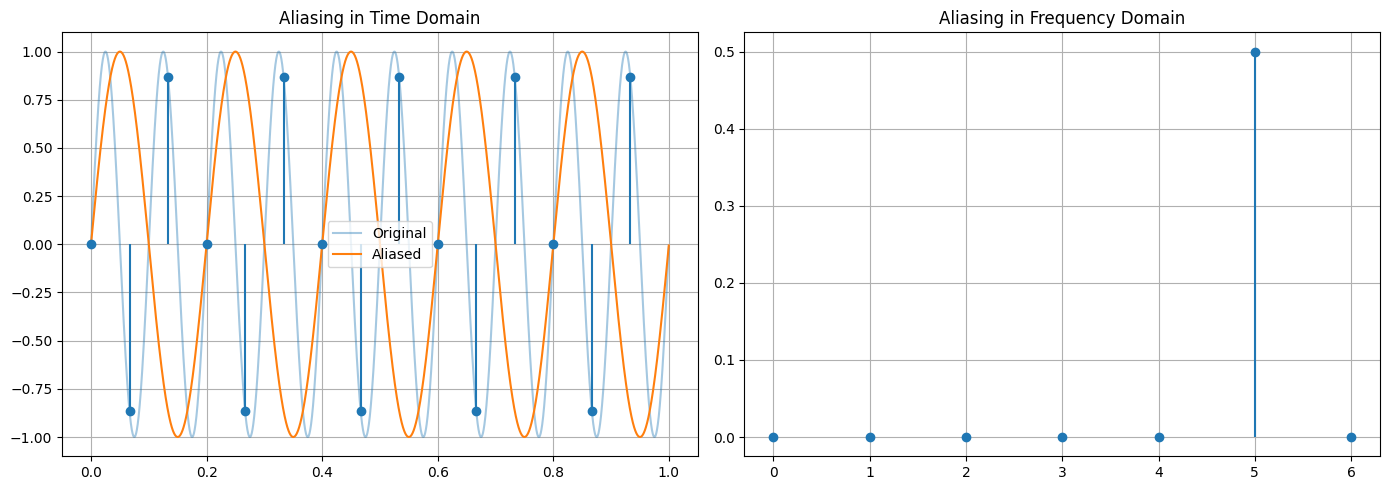

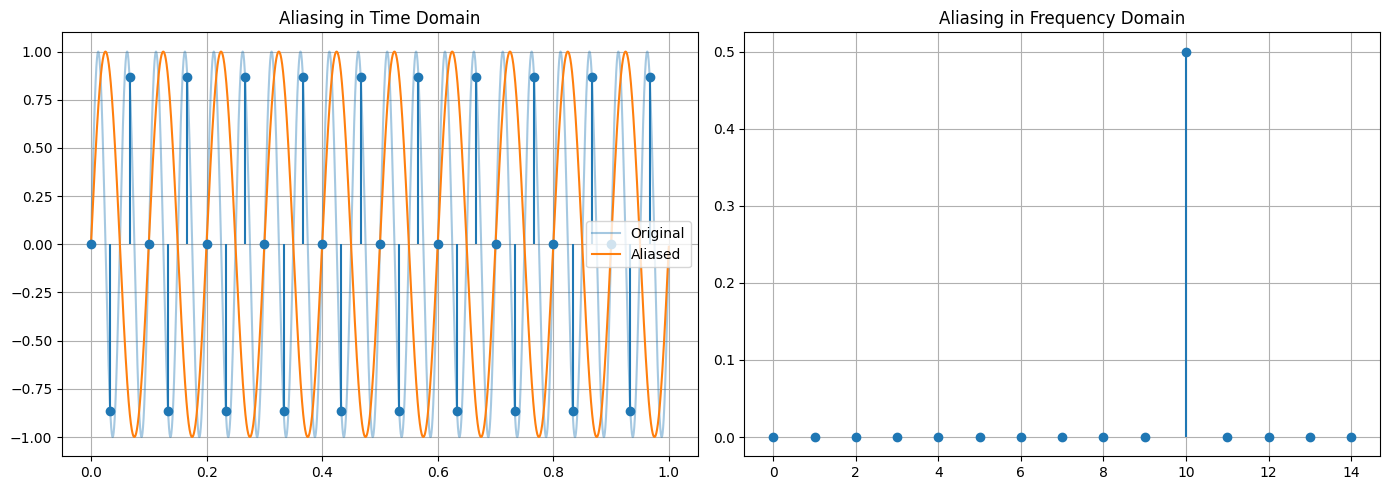

In [ ]:
alias_demo(10, 15)
alias_demo(20, 30)

Pada kondisi aliasing, sinyal yang disampling dengan frekuensi terlalu rendah akan terlihat seperti sinyal dengan frekuensi yang berbeda (biasanya lebih rendah). Bentuk gelombangnya tampak berubah atau terdistorsi.

Di domain frekuensi, puncak spektrum tidak lagi muncul pada frekuensi asli, melainkan bergeser ke frekuensi lain (frequency folding). Akibatnya, informasi frekuensi sebenarnya tidak dapat dikenali dengan benar.

Aliasing terjadi karena pelanggaran teorema Nyquist–Shannon, yang menyatakan bahwa frekuensi sampling minimal harus lebih dari dua kali frekuensi tertinggi sinyal:

> 𝑓𝑠 > 2𝑓𝑚𝑎𝑥


Jika frekuensi sampling lebih kecil dari batas tersebut, jarak antar sampel menjadi terlalu jauh. Sistem digital tidak memiliki cukup informasi untuk merekonstruksi bentuk gelombang asli.

Secara matematis, sinyal dengan frekuensi tinggi bisa menghasilkan kumpulan titik sampel yang identik dengan sinyal frekuensi lebih rendah. Karena sistem hanya melihat titik-titik sampel tersebut, ia akan “mengira” sinyalnya memang berfrekuensi rendah. Inilah yang menyebabkan munculnya frekuensi palsu pada hasil rekonstruksi.